Merged formulations: 32


C:\Users\nahid.salimi\AppData\Local\Temp\ipykernel_24920\3443178532.py:229: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


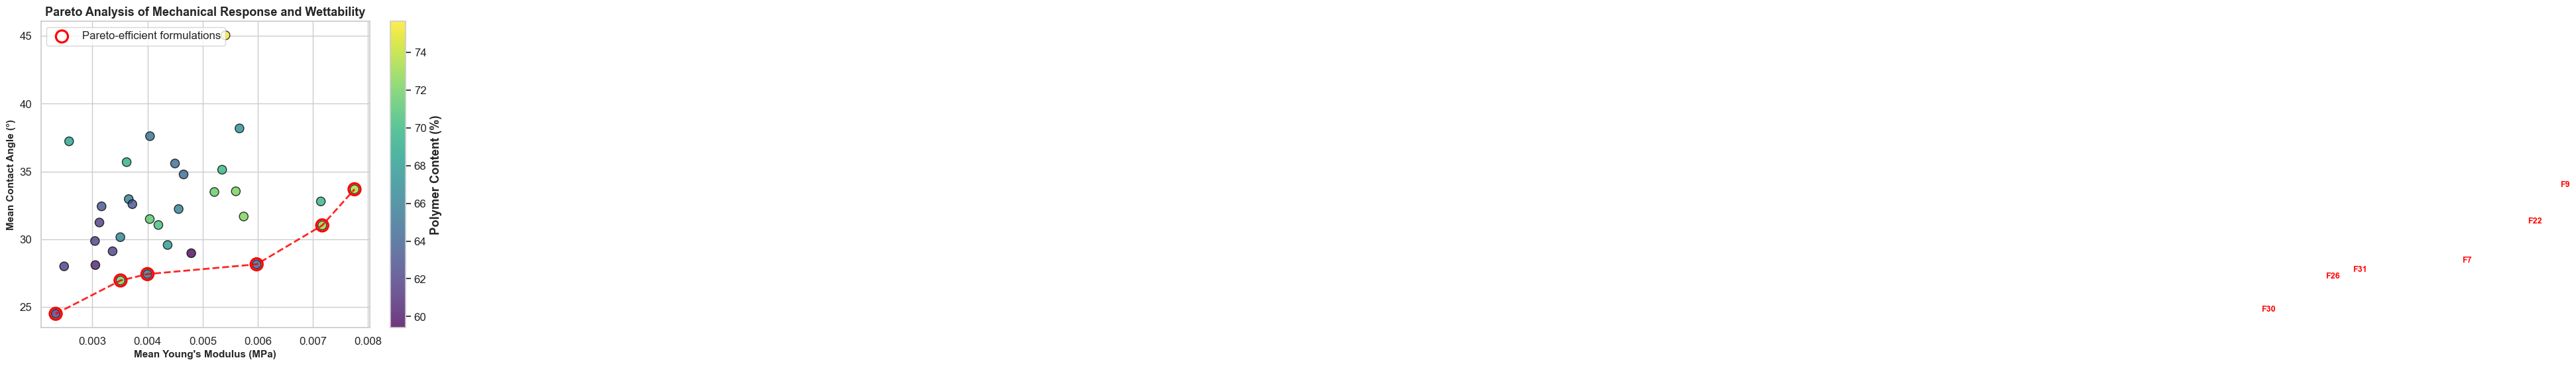


Compact Pareto table:
    Formula_ID  Mean Young's Modulus (MPa)  Mean Contact Angle (°)  \
23  Formula_30                        0.00                   24.49   
18  Formula_26                        0.00                   26.95   
24  Formula_31                        0.00                   27.42   
29   Formula_7                        0.01                   28.15   
14  Formula_22                        0.01                   31.02   
31   Formula_9                        0.01                   33.69   

    Polymer Content (%)  
23                62.11  
18                72.09  
24                65.12  
29                64.32  
14                72.97  
31                73.42  

Detailed Pareto table:
    Formula_ID  Mean Young's Modulus (MPa)  Mean Contact Angle (°)  \
23  Formula_30                        0.00                   24.49   
18  Formula_26                        0.00                   26.95   
24  Formula_31                        0.00                   27.42   


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# FILE PATHS
# ============================================================
modulus_file = "HPLW_23july_results.csv"
angle_file = "contact_angles_summary_Total.csv"

# ============================================================
# 1. LOAD CONTACT-ANGLE DATA
# ============================================================
df_ca = pd.read_csv(angle_file)
df_ca.columns = [c.strip() for c in df_ca.columns]

# Fix possible typo in formulation column
if "Fromula_ID" in df_ca.columns and "Formulation_ID" not in df_ca.columns:
    df_ca.rename(columns={"Fromula_ID": "Formulation_ID"}, inplace=True)

if "Formulation_ID" not in df_ca.columns:
    raise KeyError("No Formulation_ID column found in contact-angle file.")

required_ca_cols = [
    "Formulation_ID",
    "Average Angle (deg)",
    "HEMA (%)",
    "PEGDA (%)",
    "LAP (%)",
    "Water (%)"
]

missing_ca = [c for c in required_ca_cols if c not in df_ca.columns]
if missing_ca:
    raise KeyError(f"Missing columns in contact-angle file: {missing_ca}")

for col in required_ca_cols[1:]:
    df_ca[col] = pd.to_numeric(df_ca[col], errors="coerce")

# Mean contact angle and composition per formulation
ca_summary = (
    df_ca
    .dropna(subset=required_ca_cols)
    .groupby("Formulation_ID", as_index=False)
    .agg({
        "Average Angle (deg)": "mean",
        "HEMA (%)": "mean",
        "PEGDA (%)": "mean",
        "LAP (%)": "mean",
        "Water (%)": "mean"
    })
)

ca_summary = ca_summary.rename(columns={
    "Formulation_ID": "Formula_ID",
    "Average Angle (deg)": "Mean Contact Angle (°)"
})

ca_summary["Polymer Content (%)"] = ca_summary["HEMA (%)"] + ca_summary["PEGDA (%)"]

# ============================================================
# 2. LOAD YOUNG'S MODULUS DATA
# ============================================================
df_mod = pd.read_csv(modulus_file)
df_mod.columns = [c.strip() for c in df_mod.columns]

# Fix possible formulation column names
if "Formulation_ID" in df_mod.columns and "Formula_ID" not in df_mod.columns:
    df_mod.rename(columns={"Formulation_ID": "Formula_ID"}, inplace=True)

if "Fromula_ID" in df_mod.columns and "Formula_ID" not in df_mod.columns:
    df_mod.rename(columns={"Fromula_ID": "Formula_ID"}, inplace=True)

if "Formula_ID" not in df_mod.columns:
    raise KeyError("No Formula_ID column found in modulus file.")

# Detect Young's modulus column and convert to MPa
if "Young Modulus (MPa)" in df_mod.columns:
    modulus_col = "Young Modulus (MPa)"
    df_mod[modulus_col] = pd.to_numeric(df_mod[modulus_col], errors="coerce")

elif "Young Modulus (kPa)" in df_mod.columns:
    df_mod["Young Modulus (MPa)"] = pd.to_numeric(df_mod["Young Modulus (kPa)"], errors="coerce") / 1000.0
    modulus_col = "Young Modulus (MPa)"

elif "Young Modulus (Kpa)" in df_mod.columns:
    df_mod["Young Modulus (MPa)"] = pd.to_numeric(df_mod["Young Modulus (Kpa)"], errors="coerce") / 1000.0
    modulus_col = "Young Modulus (MPa)"

elif "E_Pa" in df_mod.columns:
    df_mod["Young Modulus (MPa)"] = pd.to_numeric(df_mod["E_Pa"], errors="coerce") / 1e6
    modulus_col = "Young Modulus (MPa)"

elif "E_Pa_Corrected" in df_mod.columns:
    df_mod["Young Modulus (MPa)"] = pd.to_numeric(df_mod["E_Pa_Corrected"], errors="coerce") / 1e6
    modulus_col = "Young Modulus (MPa)"

else:
    raise KeyError("No Young's modulus column found. Check the modulus file column names.")

# Mean Young's modulus per formulation
mod_summary = (
    df_mod
    .dropna(subset=["Formula_ID", modulus_col])
    .groupby("Formula_ID", as_index=False)
    .agg({
        modulus_col: "mean"
    })
)

mod_summary = mod_summary.rename(columns={
    modulus_col: "Mean Young's Modulus (MPa)"
})

# ============================================================
# 3. MERGE DATASETS
# ============================================================
df_pareto = pd.merge(
    mod_summary,
    ca_summary,
    on="Formula_ID",
    how="inner"
)

print("Merged formulations:", len(df_pareto))

# ============================================================
# 4. PARETO FRONT
# Objective 1: maximize Young's modulus
# Objective 2: minimize contact angle
# ============================================================
def is_pareto_efficient(data, x_col, y_col):
    is_efficient = np.ones(len(data), dtype=bool)

    for i in range(len(data)):
        x_i = data.loc[i, x_col]
        y_i = data.loc[i, y_col]

        dominated_by_other = (
            (data[x_col] >= x_i) &
            (data[y_col] <= y_i) &
            (
                (data[x_col] > x_i) |
                (data[y_col] < y_i)
            )
        )

        if dominated_by_other.any():
            is_efficient[i] = False

    return is_efficient

x_col = "Mean Young's Modulus (MPa)"
y_col = "Mean Contact Angle (°)"

df_pareto = df_pareto.reset_index(drop=True)
df_pareto["Pareto"] = is_pareto_efficient(df_pareto, x_col, y_col)

pareto_points = df_pareto[df_pareto["Pareto"]].sort_values(by=x_col).copy()

# Short formula labels
pareto_points["Short_ID"] = pareto_points["Formula_ID"].astype(str).str.replace("Formula_", "F", regex=False)

# ============================================================
# 5. PLOT SINGLE PARETO FRONT
# ============================================================
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(8, 6))

# All formulations
scatter = plt.scatter(
    df_pareto[x_col],
    df_pareto[y_col],
    c=df_pareto["Polymer Content (%)"],
    cmap="viridis",
    s=90,
    edgecolors="black",
    alpha=0.78
)

# Pareto-efficient formulations
plt.scatter(
    pareto_points[x_col],
    pareto_points[y_col],
    s=170,
    facecolors="none",
    edgecolors="red",
    linewidths=2.3,
    label="Pareto-efficient formulations"
)

# Connect Pareto front
plt.plot(
    pareto_points[x_col],
    pareto_points[y_col],
    color="red",
    linewidth=2,
    linestyle="--",
    alpha=0.85
)

# Label Pareto points
for _, row in pareto_points.iterrows():
    plt.text(
        row[x_col] + 0.04,
        row[y_col] + 0.15,
        row["Short_ID"],
        fontsize=9,
        fontweight="bold",
        color="red"
    )

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Polymer Content (%)", fontweight="bold")

plt.xlabel("Mean Young's Modulus (MPa)", fontweight="bold", fontsize=11)
plt.ylabel("Mean Contact Angle (°)", fontweight="bold", fontsize=11)

plt.title(
    "Pareto Analysis of Mechanical Response and Wettability",
    fontweight="bold",
    fontsize=13
)

plt.legend(frameon=True, loc="best")
plt.tight_layout()

plt.savefig("pareto_modulus_contact_angle.png", dpi=300, bbox_inches="tight")
plt.savefig("pareto_modulus_contact_angle.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 6. SAVE PARETO TABLES
# ============================================================

# Compact table for main text
pareto_compact = pareto_points[
    [
        "Formula_ID",
        "Mean Young's Modulus (MPa)",
        "Mean Contact Angle (°)",
        "Polymer Content (%)"
    ]
].copy()

pareto_compact["Mean Young's Modulus (MPa)"] = pareto_compact["Mean Young's Modulus (MPa)"].round(2)
pareto_compact["Mean Contact Angle (°)"] = pareto_compact["Mean Contact Angle (°)"].round(2)
pareto_compact["Polymer Content (%)"] = pareto_compact["Polymer Content (%)"].round(2)

pareto_compact.to_csv("pareto_compact_table.csv", index=False)

# Detailed table if needed for appendix
pareto_detailed = pareto_points[
    [
        "Formula_ID",
        "Mean Young's Modulus (MPa)",
        "Mean Contact Angle (°)",
        "Polymer Content (%)",
        "HEMA (%)",
        "PEGDA (%)",
        "LAP (%)",
        "Water (%)"
    ]
].copy()

for col in pareto_detailed.columns:
    if col != "Formula_ID":
        pareto_detailed[col] = pareto_detailed[col].round(2)

pareto_detailed.to_csv("pareto_detailed_table.csv", index=False)

print("\nCompact Pareto table:")
print(pareto_compact)

print("\nDetailed Pareto table:")
print(pareto_detailed)